<a href="https://colab.research.google.com/github/safeai-snu/finance_ai_2025/blob/main/day2/part1/%EC%8B%A4%EC%8A%B52_2_%EB%B9%84%EC%A7%80%EB%8F%84_%ED%95%99%EC%8A%B5%EB%B2%95_%EA%B8%B0%EB%B0%98_Auto_Encoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 오토인코더(Autoencoder)를 활용한 신용카드 이상거래 탐지 실습

이 노트북은 **Autoencoder 기반 이상거래(Fraud Detection)** 탐지 모델을 구축하고 평가하는 전체 흐름을 실습합니다. 실제 신용카드 거래 데이터를 활용하여 **비지도학습 기반의 이상 탐지** 모델을 구현하며, 주요 내용은 다음과 같습니다:

---

## ✅ 실습 목표

- **Autoencoder를 활용한 비지도 이상거래 탐지 모델 구현**
- **정상 거래를 기반으로 학습 후 재구성 오차로 이상 여부 판별**
- **MAE/MSE 기반 Top-N 방식의 평가 및 시각화**
- **재구성 오차 분포 분석을 통한 이상 탐지 기준 도출**

---

## 🧰 사용 라이브러리

- **Pandas / NumPy**: 데이터 처리 및 수치 계산  
- **Matplotlib / Seaborn**: 시각화  
- **TensorFlow / Keras**: Autoencoder 모델 정의 및 학습  
- **Scikit-learn**: 데이터 분할, 정규화, 평가 지표  
- **KaggleHub**: 실습용 크레딧카드 데이터 로딩  

---

## 📌 분석 흐름 요약

1. **데이터 로딩 및 전처리**
   - `Amount` 피처 정규화 및 `Time` 피처 제거
   - `Class` 기준으로 사기 여부 시각화

2. **Autoencoder 모델 구성**
   - 인코더-디코더 아키텍처 정의
   - `tanh`, `LeakyReLU`, `BatchNormalization` 적용
   - L1 정규화로 과적합 방지

3. **모델 학습 및 평가**
   - 전체 데이터를 대상으로 자기복원 학습 (비지도)
   - 학습 중 MAE/MSE 추적 및 시각화

4. **재구성 오차 기반 이상거래 탐지**
   - 정상 거래로 학습한 모델을 전체/테스트/사기 거래에 적용
   - 재구성 오차(MAE, MSE)를 기준으로 이상 탐지
   - Top-N 방식으로 사기 거래 탐지 성능 측정

5. **이상 탐지 결과 시각화**
   - 사기 거래와 정상 거래 간의 오차 분포 비교
   - 점그래프(Scatter plot)로 직관적 이상 분리 가능성 확인

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# 필요한 라이브러리 불러오기
import warnings
warnings.filterwarnings("ignore")
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#plt.style.use('seaborn')
import tensorflow as tf
import seaborn as sns
from sklearn.model_selection import train_test_split
from keras.models import Model, load_model
from keras.layers import Input, Dense,LeakyReLU,BatchNormalization
from keras.callbacks import ModelCheckpoint
from keras import regularizers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, precision_recall_curve


## 📊 데이터 요약 및 오토인코더 개념 정리

### 🕵️‍♀️ 신용카드 사기란?

신용카드 사기란 **타인의 신용카드를 무단으로 사용하거나**, **허위 정보를 통해 카드를 신청**, 혹은 **가짜 카드를 제조**하여 부정하게 이득을 취하는 행위를 말합니다.  
대표적인 유형은 다음과 같습니다:

- 카드 분실/도난 후 무단 사용  
- 허위 정보로 카드 발급 신청  
- 가짜 카드(복제 카드) 제작 및 사용  

> 특히, 전체 사기 사건의 **60% 이상이 가짜 신용카드**를 통한 범죄로 파악되며, 이는 조직적인 구조를 가지는 경향이 있습니다.

---

### 📂 데이터셋 개요

이 데이터셋은 **2013년 9월, 유럽의 카드 소유자**의 실거래 정보를 기반으로 수집되었습니다.

- 총 거래 수: **284,807건**
- 사기 거래: **492건 (0.172%)**
- **Class 컬럼**:  
  - `0` → 정상 거래  
  - `1` → 사기 거래  
- **Time**: 기준 거래 이후 경과 시간 (초 단위)  
- **Amount**: 거래 금액 (스케일 조정 필요)  
- **V1 ~ V28**: PCA로 비식별화된 주요 특징 변수  
- 데이터는 **심각한 클래스 불균형** 문제를 가지고 있음

---

### 🤖 오토인코더란?

오토인코더(Autoencoder)는 **입력을 압축하고 다시 복원하는 신경망 구조**입니다.  
고등학생에게 설명하듯 쉽게 말하면:

> 마치 너무 작은 가방에 많은 과제를 넣을 때, **중요한 과제만 챙기고** 나중에 다시 꺼내 펼치는 과정과 유사합니다.  
> - 인코더: 중요한 정보만 추출해 "압축"  
> - 디코더: 압축된 정보를 기반으로 "복원"

하지만 복원된 데이터는 **원본과 완전히 동일하지 않을 수 있습니다**, 왜냐하면 압축 과정에서 일부 정보가 손실되기 때문이죠.

---

### 🔍 오토인코더와 이상 탐지

- 오토인코더는 **정상 거래만 학습**하고,  
- 이후 입력 데이터를 복원했을 때의 **재구성 오차(MSE, MAE)**를 기준으로  
- **사기 거래 여부를 판별**합니다.

사기 거래는 학습되지 않았기 때문에 복원이 잘 되지 않고, 결과적으로 오차가 커집니다. 이를 활용해 이상 여부를 판단하는 것이죠.

---

### 🧠 오토인코더 vs PCA

| 항목 | 오토인코더 | PCA |
|------|-------------|-----|
| 차원 축소 방식 | 비선형 (비선형 활성화 함수 사용) | 선형 |
| 학습 방식 | 신경망 기반 학습 | 선형 변환 기반 |
| 표현력 | 복잡하고 유연한 구조 가능 | 단순 선형 조합 |
| 응용 | 이상 탐지, 노이즈 제거, 이미지 생성 등 | 주로 데이터 압축과 시각화 |

---

### 📌 구조 요약

- **입력 차원**: 예를 들어 10차원  
- **인코더**: 차원을 점점 줄여서 **핵심 표현(3차원)** 생성  
- **디코더**: 다시 10차원으로 복원  
- 결과적으로 복원 오차를 통해 **이상치(사기 거래)** 여부를 판별

이러한 특성을 활용해 오토인코더는 **효과적인 이상 탐지 도구**로 널리 사용됩니다.


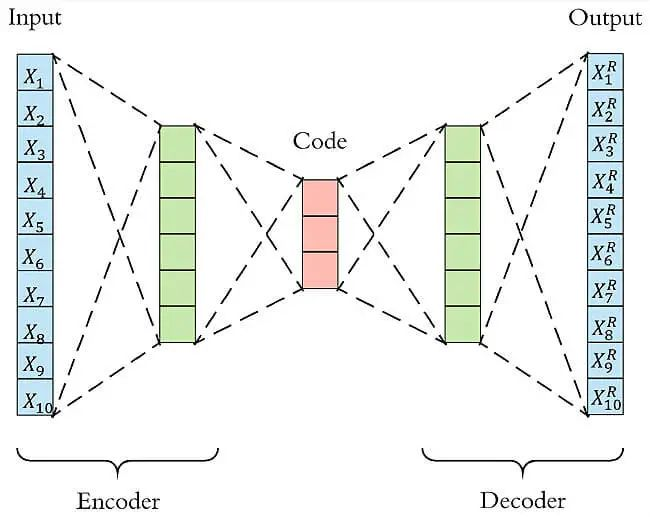

이상 탐지(anomaly detection)는 일반적으로 지도 학습과 비지도 학습 두 가지로 나뉩니다. 비지도 학습의 경우, 우리는 학습을 위해 사용할 이상 샘플을 가지고 있지 않으며, 알고리즘은 기본적으로 이상치가 다른 분포를 따른다고 가정합니다. 정상 데이터를 통해 훈련된 Autoencoder는 정상 샘플을 재구성할 수 있지만, 정상 분포와 다른 데이터 포인트는 잘 재구성하지 못하며, 이로 인해 재구성 오차가 커집니다.

만약 샘플의 특성이 모두 수치형 변수라면, 우리는 MSE(평균 제곱 오차)나 MAE(평균 절대 오차)를 재구성 오차로 사용할 수 있습니다.

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

d = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  "creditcard.csv"
)

100%|██████████| 66.0M/66.0M [00:02<00:00, 31.1MB/s]

Extracting zip of creditcard.csv...


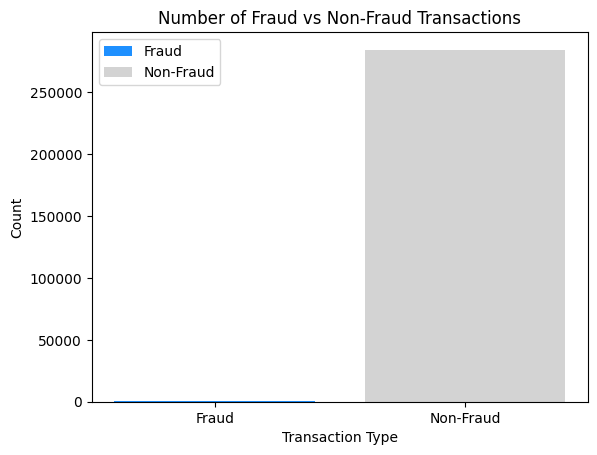

In [4]:
num_nonfraud = np.sum(d['Class'] == 0)  # 'Class' 열에서 값이 0인 비사기 거래의 개수를 계산합니다.
num_fraud = np.sum(d['Class'] == 1)  # 'Class' 열에서 값이 1인 사기 거래의 개수를 계산합니다.

fraud_label = 'Fraud'  # 사기 거래를 나타내는 레이블입니다.
nonfraud_label = 'Non-Fraud'  # 비사기 거래를 나타내는 레이블입니다.

fraud_count = [num_fraud]  # 사기 거래 개수를 리스트에 담습니다.
nonfraud_count = [num_nonfraud]  # 비사기 거래 개수를 리스트에 담습니다.

plt.bar(fraud_label, fraud_count, color='dodgerblue', label='Fraud')  # 사기 거래를 나타내는 막대 그래프를 생성합니다.
plt.bar(nonfraud_label, nonfraud_count, color='lightgrey', label='Non-Fraud')  # 비사기 거래를 나타내는 막대 그래프를 생성합니다.

plt.xlabel('Transaction Type')  # x축 레이블을 설정합니다.
plt.ylabel('Count')  # y축 레이블을 설정합니다.
plt.title('Number of Fraud vs Non-Fraud Transactions')  # 그래프의 제목을 설정합니다.

plt.legend()  # 범례를 표시합니다.
plt.show()  # 그래프를 출력합니다.

### 실행 단계
1. 'Class' 열에서 값이 0인 비사기 거래의 개수를 계산합니다.
2. 'Class' 열에서 값이 1인 사기 거래의 개수를 계산합니다.
3. 사기 거래를 나타내는 레이블을 정의합니다.
4. 비사기 거래를 나타내는 레이블을 정의합니다.
5. 사기 거래 개수를 리스트에 담습니다.
6. 비사기 거래 개수를 리스트에 담습니다.
7. 사기 거래를 나타내는 막대 그래프를 생성하고, 색상과 레이블을 설정합니다.
8. 비사기 거래를 나타내는 막대 그래프를 생성하고, 색상과 레이블을 설정합니다.
9. x축 레이블을 설정합니다.
10. y축 레이블을 설정합니다.
11. 그래프의 제목을 설정합니다.
12. 범례를 표시합니다.
13. 그래프를 출력합니다.

In [5]:
data = d.drop(['Time'], axis=1)  # 'Time' 열을 제거한 데이터프레임을 생성합니다.
data['Amount'] = StandardScaler().fit_transform(data[['Amount']])  # 'Amount' 열의 데이터를 표준화(StandardScaler)합니다.
X = data.drop(['Class'],axis=1)  # 'Class' 열을 제외한 나머지 열을 X에 할당합니다.
Y = data.Class  # 'Class' 열을 Y에 할당합니다.


1. 'Time' 열을 제거한 데이터프레임을 생성합니다.
2. 'Amount' 열의 데이터를 표준화(StandardScaler)합니다. 이는 'Amount' 열의 값들을 평균과 표준편차를 기준으로 표준화하여 데이터의 스케일을 맞추는 작업입니다.
3. 'Class' 열을 제외한 나머지 열을 X에 할당합니다. 이는 입력 데이터로 사용될 특성(독립 변수)들을 의미합니다.
4. 'Class' 열을 Y에 할당합니다. 이는 출력 데이터로 사용될 타깃(종속 변수)을 의미합니다.

In [6]:
# Autoencoder의 파라미터 설정
input_dim = X.shape[1]  # 입력 차원 설정
encoding_dim = 128  # 인코딩 차원 설정
num_epoch = 30  # 에포크 횟수 설정
batch_size = 256  # 배치 크기 설정

input_layer = Input(shape=(input_dim, ))  # 입력 레이어 정의

# 인코더 레이어 정의
encoder = Dense(encoding_dim,
                activation="tanh",
                activity_regularizer=regularizers.l1(10e-5)
                )(input_layer)  # 인코딩 레이어 설정 및 활성화 함수, 정규화 설정
encoder = BatchNormalization()(encoder)  # 배치 정규화 적용
encoder = LeakyReLU(alpha=0.2)(encoder)  # LeakyReLU 활성화 함수 적용

encoder = Dense(int(encoding_dim/2),
                activation="relu"
                )(encoder)  # 인코딩 레이어 설정 및 활성화 함수
encoder = BatchNormalization()(encoder)  # 배치 정규화 적용
encoder = LeakyReLU(alpha=0.1)(encoder)  # LeakyReLU 활성화 함수 적용

encoder = Dense(int(encoding_dim/4),
                activation="relu"
                )(encoder)  # 인코딩 레이어 설정 및 활성화 함수
encoder = BatchNormalization()(encoder)  # 배치 정규화 적용

# 디코더 레이어 정의
decoder = LeakyReLU(alpha=0.1)(encoder)  # LeakyReLU 활성화 함수 적용
decoder = Dense(int(encoding_dim/4),
                activation='tanh'
                )(decoder)  # 디코딩 레이어 설정 및 활성화 함수
decoder = BatchNormalization()(decoder)  # 배치 정규화 적용
decoder = LeakyReLU(alpha=0.1)(decoder)  # LeakyReLU 활성화 함수 적용

decoder = Dense(int(encoding_dim/2),
                activation='tanh'
                )(decoder)  # 디코딩 레이어 설정 및 활성화 함수
decoder = BatchNormalization()(decoder)  # 배치 정규화 적용
decoder = LeakyReLU(alpha=0.1)(decoder)  # LeakyReLU 활성화 함수 적용

decoder = Dense(input_dim,
                # activation='relu'
                )(decoder)  # 디코딩 레이어 설정

autoencoder = Model(inputs=input_layer,
                    outputs=decoder
                    )  # Autoencoder 모델 정의

autoencoder.compile(optimizer='adam',
                    loss='mean_squared_error',
                    metrics=['mae','mse']
                    )  # 모델 컴파일


### 작업 내용 설명

위 코드는 Autoencoder의 설정과 인코더 및 디코더 레이어를 정의하는 작업입니다. 주석을 통해 각 줄이 어떤 역할을 하는지 설명하였습니다.

1. 입력 차원을 설정합니다. X.shape[1]은 입력 데이터의 열 개수를 나타냅니다.
2. 인코딩 차원을 설정합니다. 이는 인코더 레이어에서 출력되는 차원을 의미합니다.
3. 에포크 횟수를 설정합니다. 모델이 훈련할 때 전체 데이터셋을 몇 번 반복할지를 결정합니다.
4. 배치 크기를 설정합니다. 한 번에 모델이 처리할 데이터의 개수입니다.

6-22. 인코더와 디코더 레이어를 정의합니다. Dense 함수를 사용하여 레이어를 생성하고 활성화 함수, 정규화 등을 설정합니다. LeakyReLU 함수를 사용하여 LeakyReLU 활성화 함수를 적용합니다. BatchNormalization 함수를 사용하여 배치 정규화를 적용합니다.

24-29. Autoencoder 모델을 정의합니다. Model 함수를 사용하여 입력 레이어와 출력 레이어를 지정하여 모델을 생성합니다.

모델을 컴파일합니다. compile 함수를 사용하여 옵티마이저, 손실 함수, 평가 지표 등을 설정합니다.
이렇게 작성된 코드는 Autoencoder 모델을 설정하고 컴파일하는 작업을 수행합니다.

위의 코드에서 사용된 Batch Normalization에 대한 추가 설명은 아래를 참고하시기 바랍니다.

#### 🧪 Batch Normalization이란?

**Batch Normalization**은 딥러닝 모델의 학습을 **더 빠르고 안정적으로 만드는 기술**입니다.  
각 층의 입력을 정규화하여 **학습 과정에서의 내부 공변량 변화(Internal Covariate Shift)**를 줄이는 데 도움을 줍니다.

#### ✅ 주요 효과
- **학습 속도 향상**: 더 높은 learning rate 사용 가능  
- **과적합 방지**: 일종의 정규화 효과  
- **초기 가중치 설정에 덜 민감함**  
- **더 깊은 네트워크 학습 가능**

> 일반적으로 Dense 또는 Conv 레이어 뒤에 추가되며, 활성화 함수 앞에 위치합니다.


In [7]:
# 모델 체크포인트 콜백 생성
checkpointer = ModelCheckpoint(
    filepath="autoencoder_model.h5",   # 최적 모델을 저장할 파일 경로
    verbose=0,                         # 로그 출력 수준 (0이면 출력 안 함)
    save_best_only=True               # 검증 손실 기준으로 가장 성능 좋은 모델만 저장
)

- ModelCheckpoint 객체를 생성합니다. 이 객체는 모델의 가중치를 저장하기 위해 사용됩니다.
- filepath 매개변수에는 모델 가중치를 저장할 파일 경로를 지정합니다. 여기서는 "autoencoder_model.h5"로 설정했습니다.
- verbose 매개변수는 진행 상황 출력을 제어하는 것으로, 0으로 설정하면 출력하지 않습니다.
- save_best_only 매개변수를 True로 설정하면, 모델의 성능이 이전보다 향상된 경우에만 모델 가중치를 저장합니다.

In [8]:
# 오토인코더 학습
history = autoencoder.fit(
    X,                                    # 입력값 (Autoencoder는 입력과 출력이 동일)
    X,                                    # 출력값 (자기 자신을 복원하는 방식)
    epochs=num_epoch,                     # 총 학습 반복 횟수
    batch_size=batch_size,                # 배치 단위 크기 (병렬 처리에 영향)
    shuffle=True,                         # 에폭마다 데이터 순서를 섞어 학습 성능 향상
    # validation_data=(X_test, X_test),   # 검증 데이터를 지정하면 과적합 확인 가능
    verbose=1,                            # 학습 로그 출력 (1: 프로그레스바 형태)
    callbacks=[checkpointer]              # 체크포인트 콜백을 통해 최적 모델 저장
).history                                 # 학습 결과(손실 등 기록)를 history에 저장

Epoch 1/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - loss: 1.1331 - mae: 0.4750 - mse: 0.6003
Epoch 2/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.2944 - mae: 0.2792 - mse: 0.2177
Epoch 3/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.2178 - mae: 0.2331 - mse: 0.1538
Epoch 4/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.2005 - mae: 0.2066 - mse: 0.1304
Epoch 5/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.1628 - mae: 0.1874 - mse: 0.1047
Epoch 6/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.1555 - mae: 0.1755 - mse: 0.0969
Epoch 7/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.1293 - mae: 0.1606 - mse: 0.0797
Epoch 8/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.1441 - mae: 0.1559 - mse: 0.0838
Epoch 9/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.1374 - mae: 0.1504 - mse: 0.0804
Epoch 10/30
1113/1113 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 0.1050 - mae: 0.1390 - mse: 0.0621
Epoch 11/30
1113/1113 ━━

* autoencoder 모델에 대해 fit 메서드를 호출하여 모델을 훈련시킵니다.
* 첫 번째 인자인 X는 입력 데이터입니다. 여기서는 입력과 출력이 동일한 값을 가지므로 X를 두 번 사용했습니다.
* epochs 매개변수에는 에포크 횟수를 설정합니다. 이전에 설정한 num_epoch 값을 사용합니다.
* batch_size 매개변수에는 배치 크기를 설정합니다. 이전에 설정한 batch_size 값을 사용합니다.
* shuffle 매개변수를 True로 설정하면, 각 에포크마다 데이터를 섞습니다.
* 주석 처리된 validation_data는 모델 훈련 과정에서 검증 데이터를 사용할 경우에 설정합니다.
* verbose 매개변수는 훈련 과정의 진행 상황 출력을 제어하는 것으로, 1로 설정하면 출력합니다.
* callbacks 매개변수에는 콜백 함수를 리스트로 전달합니다. 여기서는 checkpointer를 사용하여 모델 가중치를 저장하는 콜백을 등록했습니다.
* history 변수에는 훈련 과정의 손실 및 평가 지표 값을 저장합니다. .history 속성을 사용하여 접근할 수 있습니다.

이렇게 작성된 코드는 모델을 훈련시키고, 훈련 과정에서 최적의 모델 가중치를 "autoencoder_model.h5" 파일로 저장하는 작업을 수행합니다.

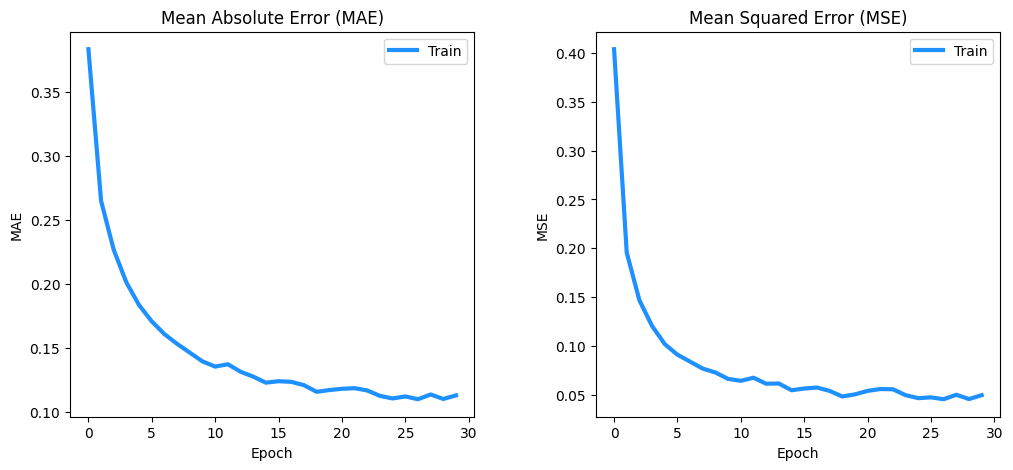

In [9]:
# MAE 그래프
plt.subplot(121)
plt.plot(history['mae'], c='dodgerblue', lw=3)
plt.title('Mean Absolute Error (MAE)')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper right')

# MSE 그래프
plt.subplot(122)
plt.plot(history['mse'], c='dodgerblue', lw=3)
plt.title('Mean Squared Error (MSE)')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend(['Train'], loc='upper right')

plt.subplots_adjust(wspace=0.3)  # 그래프 사이 간격 조정
plt.gcf().set_size_inches(12, 5)  # 그래프의 가로 길이 조정

plt.show()


위 코드는 모델 훈련 과정에서의 손실 함수(MSE), 평균 절대 오차(MAE), 평균 제곱 오차(MSE)의 변화를 그래프로 나타내는 작업입니다.

* MAE 그래프: 훈련 과정에서 MAE 값의 변화를 나타냅니다.
* MSE 그래프: 훈련 과정에서 MSE 값의 변화를 나타냅니다.

In [10]:
# 훈련된 오토인코더를 사용하여 테스트 세트를 재구성합니다.
pred_X = autoencoder.predict(X)

# 재구성 오차(MSE와 MAE)를 계산합니다.
mse_X = np.mean(np.power(X - pred_X, 2), axis=1)
mae_X = np.mean(np.abs(X - pred_X), axis=1)

# 재구성 오차를 데이터 DataFrame에 추가합니다.
data['mse_X'] = mse_X
data['mae_X'] = mae_X

# Top-N 정확도 평가
n = 1000
df = data.sort_values(by='mae_X', ascending=False)
top_n_df = df.head(n)
accuracy = top_n_df[top_n_df['Class'] == 1].shape[0] / n
print('Top-{} 정확도: {}'.format(n, accuracy))


8901/8901 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
Top-1000 정확도: 0.24


위 코드는 훈련된 오토인코더를 사용하여 테스트 세트를 재구성합니다. 재구성 오차(MSE와 MAE)를 계산하고, 이를 데이터 DataFrame에 추가합니다. 그 후, 상위 N개의 샘플을 추출하여 해당 샘플들 중 사기 클래스의 비율을 계산하여 Top-N 정확도를 평가합니다.

* pred_X: 오토인코더를 사용하여 입력 데이터 X의 재구성을 예측한 값
* mse_X: 입력 데이터 X와 재구성된 값 pred_X 사이의 평균 제곱 오차(MSE)
* mae_X: 입력 데이터 X와 재구성된 값 pred_X 사이의 평균 절대 오차(MAE)
* n: 상위 N개의 샘플을 선택하는데 사용되는 값
* df: 데이터를 mae_X 기준으로 내림차순으로 정렬한 DataFrame
* top_n_df: df에서 상위 N개의 샘플을 추출한 DataFrame
* accuracy: 상위 N개의 샘플 중 사기 클래스의 비율, 즉 Top-N 정확도

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


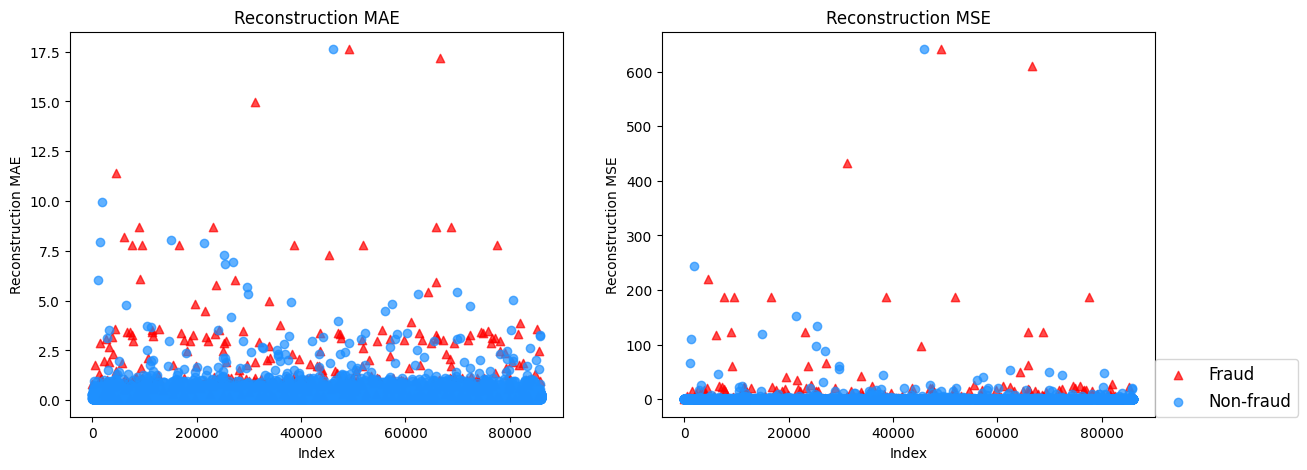

In [11]:
# 정상 거래만을 추출하여 마스크 생성
mask = (data['Class'] == 0)

# 전체 X에서 무작위로 훈련/테스트셋을 7:3 비율로 분할 (주의: 여기는 정상+사기 모두 포함된 X임)
X_train, X_test = train_test_split(X, test_size=0.3, random_state=520)

# 사기 거래(=Class가 1)만 따로 분리하여 X_fraud에 저장 (이후 비교용으로 활용)
X_fraud = X[~mask]

# 오토인코더를 이용해 테스트셋과 사기 거래 샘플을 각각 재구성
pred_test  = autoencoder.predict(X_test)
pred_fraud = autoencoder.predict(X_fraud)

# 재구성 오차 계산 (정상/사기 모두에 대해)
# MSE: 평균 제곱 오차, MAE: 평균 절대 오차
mse_test = np.mean(np.power(X_test - pred_test, 2), axis=1)
mse_fraud = np.mean(np.power(X_fraud - pred_fraud, 2), axis=1)
mae_test = np.mean(np.abs(X_test - pred_test), axis=1)
mae_fraud = np.mean(np.abs(X_fraud - pred_fraud), axis=1)

# 두 결과를 하나의 DataFrame으로 병합
mse_df = pd.DataFrame()
mse_df['Class'] = [0] * len(mse_test) + [1] * len(mse_fraud)
mse_df['MSE'] = np.hstack([mse_test, mse_fraud])
mse_df['MAE'] = np.hstack([mae_test, mae_fraud])
mse_df = mse_df.sample(frac=1).reset_index(drop=True)  # 무작위로 섞기

# 재구성 오차(MAE, MSE)를 시각화하여 사기 거래와 정상 거래 간의 차이를 비교
# 시각화를 위한 마커, 색상, 레이블 지정
# o: 정상 거래 (Non-fraud), ^: 사기 거래 (Fraud)
markers = ['o', '^']
colors = ['dodgerblue', 'red']
labels = ['Non-fraud', 'Fraud']

plt.figure(figsize=(14, 5))  # 가로 14인치, 세로 5인치 크기의 그래프 영역 생성

# === (1) MAE 시각화 ===
plt.subplot(121)  # 1행 2열 중 첫 번째 서브플롯
for flag in [1, 0]:  # 클래스 1: 사기, 클래스 0: 정상
    temp = mse_df[mse_df['Class'] == flag]  # 해당 클래스 데이터만 추출
    plt.scatter(
        temp.index,            # 인덱스 기준으로 x축
        temp['MAE'],           # y축은 MAE 값
        alpha=0.7,             # 점의 투명도
        marker=markers[flag],  # 클래스에 따른 마커 모양
        c=colors[flag],        # 클래스에 따른 색상
        label=labels[flag]     # 범례 라벨
    )
plt.title('Reconstruction MAE')         # 그래프 제목
plt.ylabel('Reconstruction MAE')        # y축 이름
plt.xlabel('Index')                     # x축 이름

# 💡 이 그래프는 정상 거래와 사기 거래의 MAE 분포를 비교합니다.
#     - 사기 거래일수록 재구성 오차(MAE)가 높게 나타나야 모델이 잘 작동하는 것입니다.

# === (2) MSE 시각화 ===
plt.subplot(122)  # 1행 2열 중 두 번째 서브플롯
for flag in [1, 0]:
    temp = mse_df[mse_df['Class'] == flag]
    plt.scatter(
        temp.index,
        temp['MSE'],
        alpha=0.7,
        marker=markers[flag],
        c=colors[flag],
        label=labels[flag]
    )
plt.legend(loc=[1, 0], fontsize=12)      # 범례 위치와 크기 지정
plt.title('Reconstruction MSE')         # 그래프 제목
plt.ylabel('Reconstruction MSE')        # y축 이름
plt.xlabel('Index')                     # x축 이름

# 💡 이 그래프는 MSE 기준으로 재구성 오차를 시각화합니다.
#     - MAE와 함께 비교하면 어떤 오차 지표가 사기 탐지에 더 효과적인지 파악할 수 있습니다.

plt.show()  # 두 서브플롯을 한 번에 출력

MAE와 MSE를 보면, 양성 및 음성 샘플 간에 상당한 차이가 있음을 알 수 있습니다. 이는 이 알고리즘이 우수한 이상 탐지 능력을 가지고 있음을 증명합니다. 그러나 일부 정상 샘플은 여전히 이상 탐지를 통해 분리하기 어렵습니다.